# PerfumeInsightLab
## Notebook 01 : Data Overview

### To-Do List
- [ ] Setup environment & dependencies
- [ ] Load dataset (`fra_cleaned.xlsx`)
- [ ] Inspect dataset (`.info()`, `.describe()`, `.head()`)
- [ ] Check missing values & duplicates
- [ ] Explore key columns: Brand, Country, Gender, Rating Value, Year, mainaccords
- [ ] Save cleaned version for processed data
- [ ] Create initial visualizations
- [ ] Summarize observations in `reports/summary.md`
      

In [8]:
# ------------------------------------------------------------------
# 1. Import libraries
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ------------------------------------------------------------------
# 2. Load dataset
# ------------------------------------------------------------------
df = pd.read_csv("../data/fra_cleaned.csv", encoding="ISO-8859-1", sep=";")


In [9]:
# ------------------------------------------------------------------
# 3. Quick Overview
# ------------------------------------------------------------------
df.shape


(24063, 18)

In [18]:
print("Shape of dataset :", df.shape) 

Shape of dataset : (24063, 18)


In [11]:
display(df.head())              # Display first few rows

,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
0,https://www.fragrantica.com/perfume/xerjoff/ac...,accento-overdose-pride-edition,xerjoff,Italy,unisex,"1,42",201,2022.0,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",unknown,NaN,rose,woody,fruity,aromatic,floral
1,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2024,jean-paul-gaultier,France,women,"1,86",70,2024.0,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",unknown,NaN,citrus,white floral,sweet,fresh,musky
2,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2023,jean-paul-gaultier,France,unisex,"1,91",285,2023.0,"blood orange, yuzu","neroli, orange blossom","musk, white woods",natalie gracia-cetto,quentin bisch,citrus,white floral,sweet,fresh spicy,musky
3,https://www.fragrantica.com/perfume/bruno-bana...,pride-edition-man,bruno-banani,Germany,men,"1,92",59,2019.0,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",unknown,NaN,fruity,nutty,woody,tropical,NaN
4,https://www.fragrantica.com/perfume/jean-paul-...,le-male-pride-collector,jean-paul-gaultier,France,men,"1,93",632,2020.0,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",francis kurkdjian,NaN,aromatic,warm spicy,fresh spicy,cinnamon,vanilla


In [17]:
print("Data Info :")            # Info about data types and non-null values
df.info()

Data Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24063 entries, 0 to 24062
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           24063 non-null  object 
 1   Perfume       24063 non-null  object 
 2   Brand         24063 non-null  object 
 3   Country       24063 non-null  object 
 4   Gender        24063 non-null  object 
 5   Rating Value  24063 non-null  object 
 6   Rating Count  24063 non-null  int64  
 7   Year          22026 non-null  float64
 8   Top           24063 non-null  object 
 9   Middle        24063 non-null  object 
 10  Base          24063 non-null  object 
 11  Perfumer1     24063 non-null  object 
 12  Perfumer2     1336 non-null   object 
 13  mainaccord1   24063 non-null  object 
 14  mainaccord2   24050 non-null  object 
 15  mainaccord3   23949 non-null  object 
 16  mainaccord4   23675 non-null  object 
 17  mainaccord5   23082 non-null  object 
dtypes: float64(1),

In [16]:
print("Descriptive Statistics :")              # Descriptive statistics (numerical + categorical)
display(df.describe(include='all'))

Descriptive Statistics :


,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
count,24063,24063,24063,24063,24063,24063,24063.000000,22026.000000,24063,24063,24063,24063,1336,24063,24050,23949,23675,23082
unique,24063,22840,1060,54,3,221,NaN,NaN,18771,19690,16393,869,259,66,71,72,69,77
top,https://www.fragrantica.com/perfume/xerjoff/ac...,vetiver,avon,France,women,4,NaN,NaN,bergamot,jasmine,musk,unknown,verônica kato,citrus,woody,woody,woody,woody
freq,1,18,578,7261,11376,504,NaN,NaN,304,162,319,12320,62,3320,2748,2507,2212,1912
mean,NaN,NaN,NaN,NaN,NaN,NaN,501.396542,2012.455961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1429.484690,13.526737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,26.000000,1781.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,56.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,127.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,360.000000,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# ------------------------------------------------------------------
# 4. Check missing values
# ------------------------------------------------------------------
missing = df.isna().sum()
print("Missing values per column :\n", missing)


Missing values per column :
 url                 0
Perfume             0
Brand               0
Country             0
Gender              0
Rating Value        0
Rating Count        0
Year             2037
Top                 0
Middle              0
Base                0
Perfumer1           0
Perfumer2       22727
mainaccord1         0
mainaccord2        13
mainaccord3       114
mainaccord4       388
mainaccord5       981
dtype: int64


In [25]:
missing[missing > 1000]          # Check which columns have a large number of missing values

Year          2037
Perfumer2    22727
dtype: int64

In [26]:
duplicates = df[df.duplicated()]  # Display duplicated rows to inspect potential data repetition
duplicates.head()

,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5


In [27]:
df.nunique()                      # Count the number of unique values in each column

url             24063
Perfume         22840
Brand            1060
Country            54
Gender              3
Rating Value      221
Rating Count     2721
Year              145
Top             18771
Middle          19690
Base            16393
Perfumer1         869
Perfumer2         259
mainaccord1        66
mainaccord2        71
mainaccord3        72
mainaccord4        69
mainaccord5        77
dtype: int64

In [28]:
df['Brand'].value_counts().head(10)          # Show the most frequent values for main categorical columns
df['Country'].value_counts().head(10)
df['Gender'].value_counts()

Gender
women     11376
unisex     7698
men        4989
Name: count, dtype: int64

<Axes: >

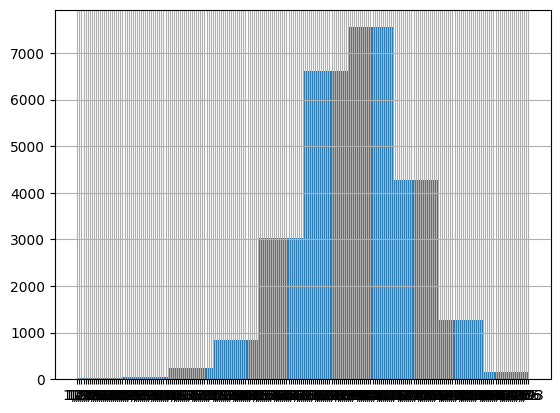

In [34]:
df['Rating Value'].hist(bins=10)             # Visualize the distribution of ratings

In [36]:
df.corr(numeric_only=True)         # Compute correlations only for numeric columns

,Rating Count,Year
Rating Count,1.000000,-0.099401
Year,-0.099401,1.000000


In [37]:
# ------------------------------------------------------------------
# 5. Check duplicates
# ------------------------------------------------------------------
duplicates = df.duplicated().sum()
print("Number of duplicated rows :", duplicates)


Number of duplicated rows : 0
